<a href="https://colab.research.google.com/github/maheshkumar30/DataScience/blob/main/Walmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Load & inspect**

In [ ]:
import pandas as pd

df = pd.read_csv("Walmart DataSet.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

**Convert Date column**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

**Missing Values Handling**

In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Year,0
Month,0


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

**Outlier Detection**

Use boxplot or IQR method:

<Axes: ylabel='Weekly_Sales'>

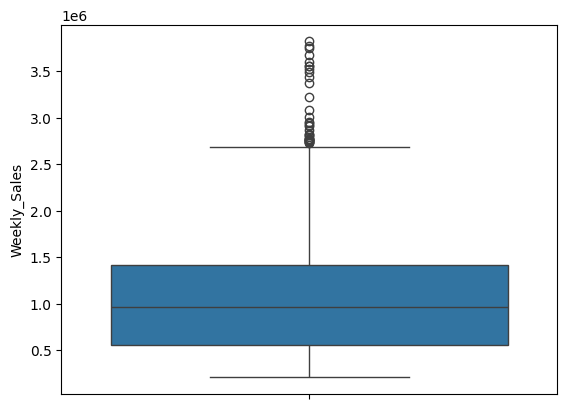

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Weekly_Sales'])

In [ ]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Weekly_Sales'] >= Q1 - 1.5*IQR) &
        (df['Weekly_Sales'] <= Q3 + 1.5*IQR)]

#**Sales vs Unemployment**

Correlation

In [ ]:
df[['Weekly_Sales', 'Unemployment']].corr()

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.104298
Unemployment,-0.104298,1.000000


**Store-wise impact**

In [ ]:
store_corr = df.groupby('Store')[['Weekly_Sales','Unemployment']].corr().iloc[0::2,-1]
store_corr.sort_values()

,,Unemployment
Store,,
38,Weekly_Sales,-0.785290
44,Weekly_Sales,-0.780076
4,Weekly_Sales,-0.639563
13,Weekly_Sales,-0.400254
39,Weekly_Sales,-0.384681
42,Weekly_Sales,-0.356355
41,Weekly_Sales,-0.350630
17,Weekly_Sales,-0.263600
3,Weekly_Sales,-0.230413


**Insight:**
1. Negative correlation → higher unemployment = lower sales
2. Stores with strong negative correlation are suffering most

#**Seasonal Trends**
Monthly sales trend

<Axes: xlabel='Month'>

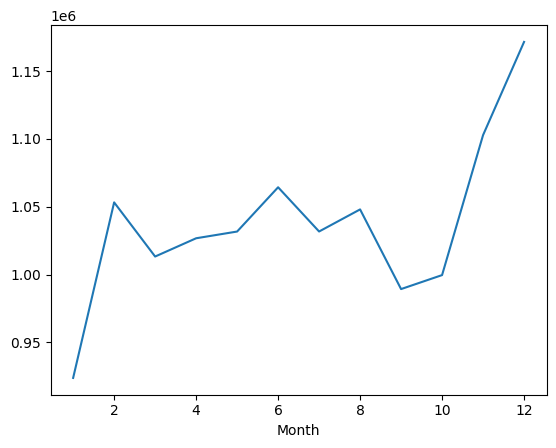

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot()

Holiday effect

In [ ]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

,Weekly_Sales
Holiday_Flag,
0,1.032370e+06
1,1.086950e+06


**Insight:**
1. Sales usually spike during:
* November–December (holiday season)
* Major events (Christmas, Black Friday)

**Temperature vs Sales**

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

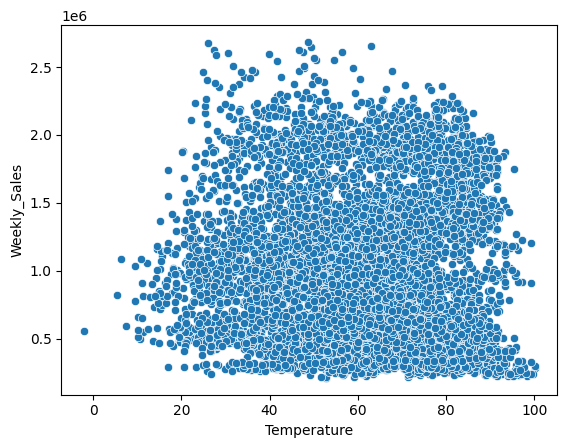

In [ ]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df)

Correlation:

In [ ]:
df[['Temperature','Weekly_Sales']].corr()

,Temperature,Weekly_Sales
Temperature,1.00000,-0.04434
Weekly_Sales,-0.04434,1.00000


**Insight:**
1. Usually weak correlation
* Some stores may show:
* High temp → lower sales (region-specific)

#**CPI vs Sales**

In [ ]:
df[['CPI','Weekly_Sales']].corr()

,CPI,Weekly_Sales
CPI,1.000000,-0.069617
Weekly_Sales,-0.069617,1.000000


**Insight:**
1. CPI reflects inflation
2. High CPI may:
    * Increase revenue (price rise)
    * Decrease volume (customer spending drops)

#**Top Performing Stores**

In [ ]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_stores.head()

,Weekly_Sales
Store,
4,2.810352e+08
20,2.800237e+08
14,2.761276e+08
2,2.687221e+08
13,2.682025e+08


#**Worst Store & Difference**

In [ ]:
worst_store = top_stores.idxmin()
best_store = top_stores.idxmax()

difference = top_stores.max() - top_stores.min()

**Insight:**
1. Compare % difference:

In [ ]:
percentage_diff = (difference / top_stores.max()) * 100

#**Forecasting (Next 12 Weeks)**


You can use multiple models:

**ARIMA (Time Series)**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

store_data = df[df['Store'] == 1].set_index('Date')
model = ARIMA(store_data['Weekly_Sales'], order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [ ]:
from prophet import Prophet

prophet_df = store_data.reset_index()[['Date','Weekly_Sales']]
prophet_df.columns = ['ds','y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df[['Store','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment','Month','Week']]
y = df['Weekly_Sales']

model = RandomForestRegressor()
model.fit(X, y)

RandomForestRegressor()